#### Problem Statement

Our aim in this project is to predict if a person would buy an iPhone with respect to their gender, age, and income.

#### 1) Importing Necessary Libraries:

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay, roc_curve, auc
from sklearn.pipeline import Pipeline

import warnings
warnings.filterwarnings('ignore')

#### 2) Loading Data:

In [2]:
df = pd.read_csv('iphone_purchase_records.csv')

In [3]:
df.head()

,Gender,Age,Salary,Purchase Iphone
0,Male,19,19000,0
1,Male,35,20000,0
2,Female,26,43000,0
3,Female,27,57000,0
4,Male,19,76000,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Gender           400 non-null    object
 1   Age              400 non-null    int64 
 2   Salary           400 non-null    int64 
 3   Purchase Iphone  400 non-null    int64 
dtypes: int64(3), object(1)
memory usage: 12.6+ KB


In [5]:
df.describe()

,Age,Salary,Purchase Iphone
count,400.000000,400.000000,400.000000
mean,37.655000,69742.500000,0.357500
std,10.482877,34096.960282,0.479864
min,18.000000,15000.000000,0.000000
25%,29.750000,43000.000000,0.000000
50%,37.000000,70000.000000,0.000000
75%,46.000000,88000.000000,1.000000
max,60.000000,150000.000000,1.000000


- We have one Categorical and feature and two numeric features.
- Target (Purchase Iphone) is categorical.

In [7]:
df['Purchase Iphone'].value_counts() /len(df) * 100

Purchase Iphone
0    64.25
1    35.75
Name: count, dtype: float64

- There's a slight class imbalance in data.
- We will use Over Sampling if necessary.

#### 3) Feature Transformations:

In [8]:
df.head()

,Gender,Age,Salary,Purchase Iphone
0,Male,19,19000,0
1,Male,35,20000,0
2,Female,26,43000,0
3,Female,27,57000,0
4,Male,19,76000,0


##### 1) Gender:

In [9]:
df['Gender'].value_counts()

Gender
Female    204
Male      196
Name: count, dtype: int64

In [10]:
gender_pipe = Pipeline([
    ('encoder', OneHotEncoder(handle_unknown= 'ignore'))
])

##### 2) Age and Salary:

In [11]:
df['Age']

0      19
1      35
2      26
3      27
4      19
       ..
395    46
396    51
397    50
398    36
399    49
Name: Age, Length: 400, dtype: int64

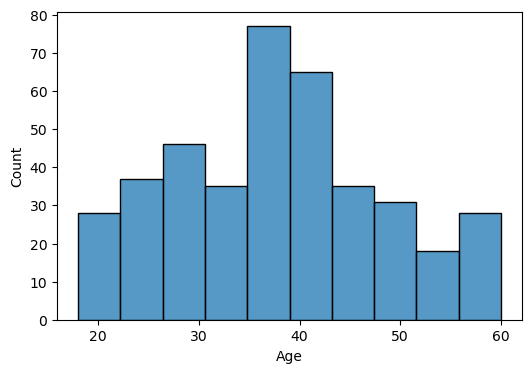

In [12]:
plt.figure(figsize= (6,4))
sns.histplot(data= df, x= 'Age')
plt.show()

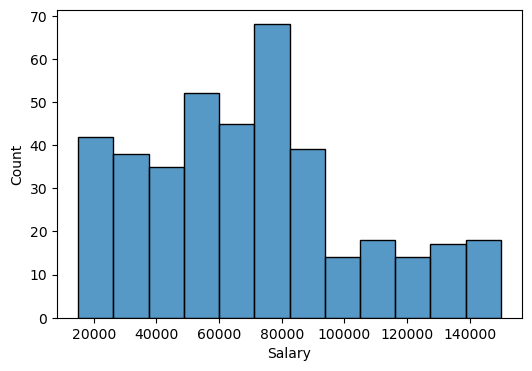

In [13]:
plt.figure(figsize= (6,4))
sns.histplot(data= df, x= 'Salary')
plt.show()

In [14]:
numeric_pipe = Pipeline([
    ('scaler', StandardScaler())
])

#### 4) Final Preprocessor:

In [18]:
preprocessor = ColumnTransformer([
    ('Gender', gender_pipe, ['Gender']),
    ('Numeric', numeric_pipe, ['Age', 'Salary'])
], remainder= 'passthrough')

#### 5) Train Test Split:

In [17]:
X = df.drop('Purchase Iphone', axis= 1) # Features
y= df['Purchase Iphone'] #Target

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state= 42)

In [20]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(320, 3)
(80, 3)
(320,)
(80,)


#### 6) Model Building and Evaluation:

In [21]:
model = Pipeline([
    ('Preprocessing', preprocessor),
    ('Model', SVC())
])

In [25]:
param_dict = {'Model__kernel': ['linear', 'poly', 'rbf', 'sigmoid'],
             'Model__C': [0.01, 0.1, 1, 10, 100],
             'Model__degree': [1, 2, 3],
             'Model__gamma': ['scale', 'auto']}

In [26]:
grid_model = GridSearchCV(estimator= model,
                         param_grid= param_dict,
                         cv= 10)

In [27]:
# Fitting the grid model:

grid_model.fit(X_train, y_train)

,estimator,"Pipeline(step...del', SVC())])"
,param_grid,"{'Model__C': [0.01, 0.1, ...], 'Model__degree': [1, 2, ...], 'Model__gamma': ['scale', 'auto'], 'Model__kernel': ['linear', 'poly', ...]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,10
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('Gender', ...), ('Numeric', ...)]"


In [28]:
# Best Estimator and Parameters according to Grid Search:

print(grid_model.best_params_)
print(grid_model.best_score_)

{'Model__C': 1, 'Model__degree': 1, 'Model__gamma': 'auto', 'Model__kernel': 'rbf'}
0.90625


In [29]:
# Predicitons using Best Estimator from Grid Search:

y_pred = grid_model.predict(X_test)

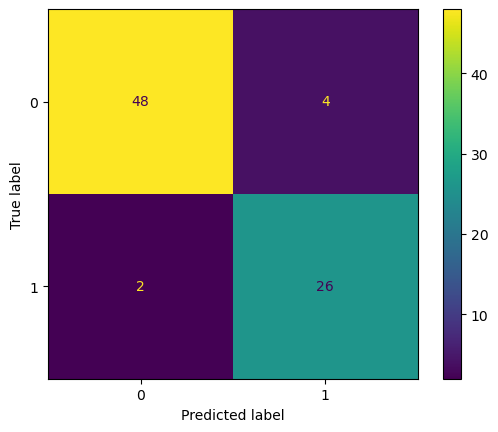

In [30]:
# Confusuion Matrix:

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels= grid_model.classes_)
disp.plot()
plt.show()

In [31]:
# Classification Report:

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.92      0.94        52
           1       0.87      0.93      0.90        28

    accuracy                           0.93        80
   macro avg       0.91      0.93      0.92        80
weighted avg       0.93      0.93      0.93        80



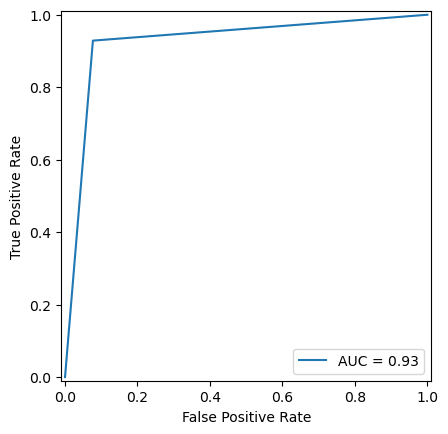

In [32]:
# ROC-AUC Curve:

fpr, tpr, thresholds = roc_curve(y_test, y_pred)
roc_auc = auc(fpr, tpr)
disp = RocCurveDisplay(fpr= fpr, tpr= tpr, roc_auc= roc_auc)
disp.plot()
plt.show()